### Setup and Hyperparameters
Imports the necessary SNN frameworks and defines the tutorial-scale knobs (batch size, learning rate, and subsets).


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from snntorch import surrogate

from mnn_torch import paths
from mnn_torch.data import ensure_mnist, mnist_loaders
from mnn_torch.effects import compute_PooleFrenkel_parameters
from mnn_torch.devices import load_SiOx_multistate
from mnn_torch.models import MSNN, MCSNN

# Default mode computes reduced-budget live results. Set to "full_sweep_cache"
# only to render the committed publication-scale cache generated by heavy sweeps.
RESULT_MODE = "live"
if RESULT_MODE not in {"live", "full_sweep_cache"}:
    raise ValueError("RESULT_MODE must be 'live' or 'full_sweep_cache'")

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- tutorial-scale knobs (small so this runs in-kernel in ~1 min on CPU) --------
BATCH_SIZE  = 64
NUM_HIDDEN  = 100
NUM_OUTPUTS = 10
NUM_INPUTS  = 28 * 28
BETA        = 0.95   # LIF membrane decay
LR          = 1e-3
EPOCHS      = 2      # passes over the training subset (many more in the full benchmark)
DISTURB_P   = 0.1    # mild device disturbance; the aggressive 0.8 stress level (used in
                     # the fault-recovery study) stalls learning at this tiny scale.
# The dense MSNN is cheap, so it gets more data/steps; the conv MCSNN is ~10x costlier
# per step, so it runs on a smaller subset with fewer timesteps to stay fast.
MSNN_STEPS,  MSNN_TRAIN_N,  MSNN_TEST_N  = 10, 3000, 500   # dense net
MCSNN_STEPS, MCSNN_TRAIN_N, MCSNN_TEST_N =  6, 1500, 400   # conv net (heavier per step)
NUM_STEPS = MSNN_STEPS  # (kept for the forward-pass loops shown below)

GREEN, INDIGO, RED, GOLD, GREY = "#3aa07a", "#2f4b8f", "#c0392b", "#e0a93b", "#9aa6b2"

def _clean(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_axisbelow(True); ax.grid(True, color="0.88", lw=0.5)

print("torch", torch.__version__, "| device:", device)
print("data dir:", paths.data_dir())
print("device fixture:", paths.device_data_mat().name)

torch 2.8.0+cu128 | device: cuda
data dir: C:\Users\User\git\mnn-torch\data
device fixture: SiO_x-multistate-data.mat


### Device Characterization
Loads the measured SiOx experimental data and fits the Poole-Frenkel multistate resistance ladder.


experimental data shape (channels, curves, points): (2, 53, 799)
fitted device states: 49 resistance states
G_off = 6.901e-04 S   G_on = 3.451e-03 S   (on/off ratio ~ 5.0)


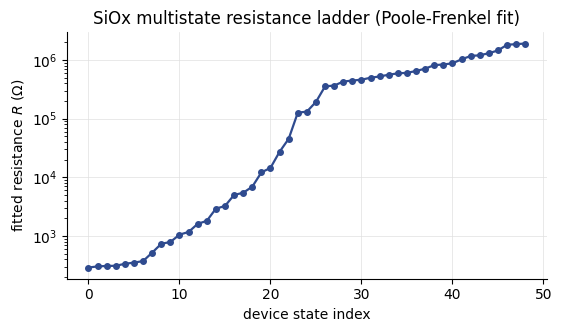

In [2]:
experimental_data = load_SiOx_multistate(paths.device_data_mat())
G_off, G_on, R, c, d_epsilon = compute_PooleFrenkel_parameters(experimental_data)

print("experimental data shape (channels, curves, points):", experimental_data.shape)
print(f"fitted device states: {len(R)} resistance states")
print(f"G_off = {G_off:.3e} S   G_on = {G_on:.3e} S   (on/off ratio ~ {G_on/G_off:.1f})")

# The Poole-Frenkel config every memristive layer consumes. disturb_conductance +
# disturb_mode='fixed' inject the measured device-to-device variability at rate
# DISTURB_P; the two homeostasis_* keys toggle the spike-rate homeostasis compared
# in the next sections.
def make_pf_config(homeostasis_dropout):
    return {
        "ideal": False, "k_V": 0.5,
        "G_off": G_off, "G_on": G_on, "R": R, "c": c, "d_epsilon": d_epsilon,
        "disturb_conductance": True, "disturb_mode": "fixed",
        "disturbance_probability": DISTURB_P,
        "homeostasis_dropout": homeostasis_dropout, "homeostasis_threshold": 10,
    }

# Plot the raw fitted resistance ladder -- the discrete multistate the device offers.
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(np.arange(len(R)), np.asarray(R, float), "-o", color=INDIGO, lw=1.6, ms=4)
ax.set_xlabel("device state index"); ax.set_ylabel(r"fitted resistance $R$ ($\Omega$)")
ax.set_yscale("log"); ax.set_title("SiOx multistate resistance ladder (Poole-Frenkel fit)")
_clean(ax); plt.show()

### Data Loading
Downloads the MNIST dataset and initializes the `DataLoader` instances for both the dense and convolutional networks.


MSNN  train batches: 46   test batches: 7
MCSNN train batches: 23   test batches: 6
batch: (64, 1, 28, 28) labels: (64,)


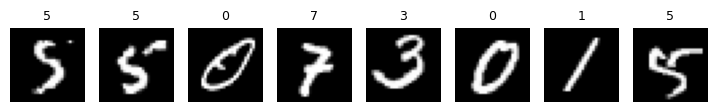

In [3]:
ensure_mnist()  # one-off download into paths.data_dir(); no-op if already present
msnn_train,  msnn_test  = mnist_loaders(
    seed=0, batch_size=BATCH_SIZE, train_subset=MSNN_TRAIN_N,  test_subset=MSNN_TEST_N)
mcsnn_train, mcsnn_test = mnist_loaders(
    seed=0, batch_size=BATCH_SIZE, train_subset=MCSNN_TRAIN_N, test_subset=MCSNN_TEST_N)

xb, yb = next(iter(msnn_train))
print(f"MSNN  train batches: {len(msnn_train)}   test batches: {len(msnn_test)}")
print(f"MCSNN train batches: {len(mcsnn_train)}   test batches: {len(mcsnn_test)}")
print("batch:", tuple(xb.shape), "labels:", tuple(yb.shape))

# A quick peek at the digits we will classify.
fig, axes = plt.subplots(1, 8, figsize=(9, 1.4))
for ax, img, lab in zip(axes, xb[:8], yb[:8]):
    ax.imshow(img.squeeze().numpy(), cmap="gray"); ax.set_title(int(lab), fontsize=9)
    ax.axis("off")
plt.show()

### Train Dense MSNN
Instantiates and trains the dense Memristive Spiking Neural Network (MSNN) over the MNIST subset, tracking accuracy with and without homeostasis.


In [4]:
def train_msnn(homeostasis_dropout):
    torch.manual_seed(0)
    net = MSNN(NUM_INPUTS, NUM_HIDDEN, NUM_OUTPUTS, MSNN_STEPS, BETA,
               make_pf_config(homeostasis_dropout)).to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    loss_hist = []
    t0 = time.time()
    for _ in range(EPOCHS):
        for data, targets in msnn_train:
            data, targets = data.to(device), targets.to(device)
            net.train()
            _, mem_rec = net(data.view(data.shape[0], -1))
            loss_val = sum(loss_fn(mem_rec[s], targets) for s in range(MSNN_STEPS))
            opt.zero_grad(); loss_val.backward(); opt.step()
            loss_hist.append(loss_val.item())
    # single pass over the held-out test subset for accuracy
    net.eval(); correct = total = 0
    with torch.no_grad():
        for data, targets in msnn_test:
            data, targets = data.to(device), targets.to(device)
            spk, _ = net(data.view(data.shape[0], -1))
            correct += (spk.sum(0).argmax(1) == targets).sum().item()
            total += targets.numel()
    acc = correct / max(total, 1)
    print(f"  MSNN homeostasis_dropout={homeostasis_dropout!s:5}  "
          f"params={sum(p.numel() for p in net.parameters()):,}  "
          f"test_acc={acc*100:5.1f}%  ({time.time()-t0:.1f}s)")
    return loss_hist, acc

print(f"Training fully-connected MSNN ({MSNN_TRAIN_N} examples, {EPOCHS} epochs):")
msnn_loss_h,  msnn_acc_h  = train_msnn(homeostasis_dropout=True)
msnn_loss_nh, msnn_acc_nh = train_msnn(homeostasis_dropout=False)

Training fully-connected MSNN (3000 examples, 2 epochs):


  MSNN homeostasis_dropout=True   params=79,510  test_acc= 71.2%  (12.6s)


  MSNN homeostasis_dropout=False  params=79,510  test_acc= 71.0%  (12.2s)


### Plot MSNN Learning Curve
Renders the live accuracy curve of the MSNN over the training steps.


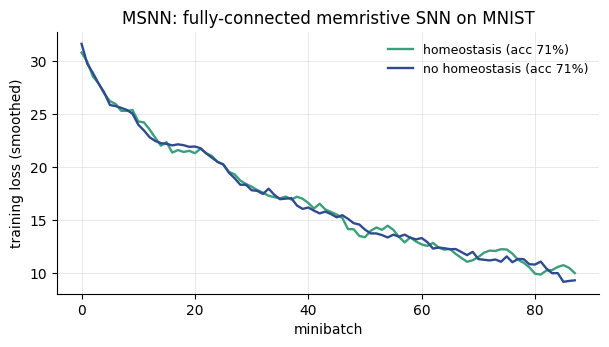

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 3.4))
def _smooth(v, w=5):
    v = np.asarray(v, float); w = min(w, len(v)) or 1
    return np.convolve(v, np.ones(w) / w, mode="valid")
ax.plot(_smooth(msnn_loss_h),  color=GREEN,  lw=1.7, label=f"homeostasis (acc {msnn_acc_h*100:.0f}%)")
ax.plot(_smooth(msnn_loss_nh), color=INDIGO, lw=1.7, label=f"no homeostasis (acc {msnn_acc_nh*100:.0f}%)")
ax.set_xlabel("minibatch"); ax.set_ylabel("training loss (smoothed)")
ax.set_title("MSNN: fully-connected memristive SNN on MNIST")
ax.legend(frameon=False, fontsize=9); _clean(ax); plt.show()

### Train Convolutional MCSNN
Instantiates and trains the heavier convolutional network (MCSNN) on a smaller subset of the data.


In [6]:
def train_mcsnn(homeostasis_dropout):
    torch.manual_seed(0)
    net = MCSNN(
        beta=BETA, spike_grad=surrogate.fast_sigmoid(slope=25), num_steps=MCSNN_STEPS,
        batch_size=BATCH_SIZE, num_kernels=5, num_conv1=12, num_conv2=64,
        max_pooling=2, num_outputs=NUM_OUTPUTS,
        memristive_config=make_pf_config(homeostasis_dropout),
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    loss_hist = []
    t0 = time.time()
    for _ in range(EPOCHS):
        for data, targets in mcsnn_train:
            data, targets = data.to(device), targets.to(device)
            net.train()
            _, mem_rec, _ = net(data)
            loss_val = sum(loss_fn(mem_rec[s], targets) for s in range(MCSNN_STEPS))
            opt.zero_grad(); loss_val.backward(); opt.step()
            loss_hist.append(loss_val.item())
    net.eval(); correct = total = 0
    with torch.no_grad():
        for data, targets in mcsnn_test:
            data, targets = data.to(device), targets.to(device)
            spk, _, _ = net(data)
            correct += (spk.sum(0).argmax(1) == targets).sum().item()
            total += targets.numel()
    acc = correct / max(total, 1)
    print(f"  MCSNN homeostasis_dropout={homeostasis_dropout!s:5}  "
          f"params={sum(p.numel() for p in net.parameters()):,}  "
          f"test_acc={acc*100:5.1f}%  ({time.time()-t0:.1f}s)")
    return loss_hist, acc

print(f"Training convolutional MCSNN ({MCSNN_TRAIN_N} examples, {EPOCHS} epochs):")
mcsnn_loss_h,  mcsnn_acc_h  = train_mcsnn(homeostasis_dropout=True)
mcsnn_loss_nh, mcsnn_acc_nh = train_mcsnn(homeostasis_dropout=False)

Training convolutional MCSNN (1500 examples, 2 epochs):


  MCSNN homeostasis_dropout=True   params=29,826  test_acc= 35.9%  (9.6s)


  MCSNN homeostasis_dropout=False  params=29,826  test_acc= 41.1%  (9.8s)


### Format Accuracies
Aggregates the final training accuracies from both network topologies into plottable arrays.


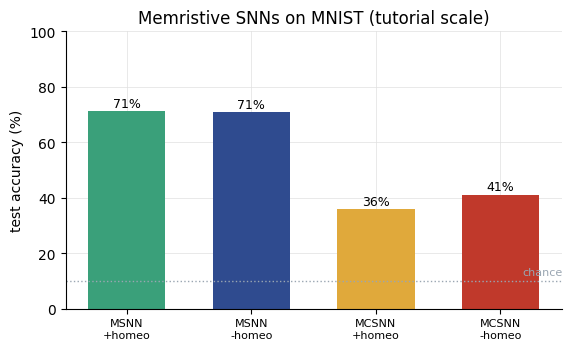

summary (test accuracy, small subset):
  MSNN +homeo   :  71.2%
  MSNN -homeo   :  71.0%
  MCSNN +homeo  :  35.9%
  MCSNN -homeo  :  41.1%


In [7]:
labels = ["MSNN\n+homeo", "MSNN\n-homeo", "MCSNN\n+homeo", "MCSNN\n-homeo"]
accs   = [msnn_acc_h, msnn_acc_nh, mcsnn_acc_h, mcsnn_acc_nh]
cols   = [GREEN, INDIGO, GOLD, RED]
fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(labels))
ax.bar(x, [a * 100 for a in accs], color=cols, width=0.62)
for xi, a in zip(x, accs):
    ax.text(xi, a * 100 + 1.5, f"{a*100:.0f}%", ha="center", fontsize=9)
ax.axhline(10, ls=":", color=GREY, lw=1.0)  # 10-class chance
ax.text(len(labels) - 0.5, 12, "chance", color=GREY, fontsize=8, ha="right")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("test accuracy (%)"); ax.set_ylim(0, max(100, max(accs) * 100 + 12))
ax.set_title("Memristive SNNs on MNIST (tutorial scale)")
_clean(ax); plt.show()

print("summary (test accuracy, small subset):")
for l, a in zip([s.replace(chr(10), ' ') for s in labels], accs):
    print(f"  {l:14s}: {a*100:5.1f}%")

### Static-classifier result panel

The default panel is computed from the live reduced-budget training runs above. Set `RESULT_MODE = "full_sweep_cache"` to render the committed publication-scale table values generated by the heavier multi-seed sweep; that path prints the cache provenance before plotting.

LIVE result: one-seed reduced subset; use RESULT_MODE='full_sweep_cache' for the committed multi-seed cache.


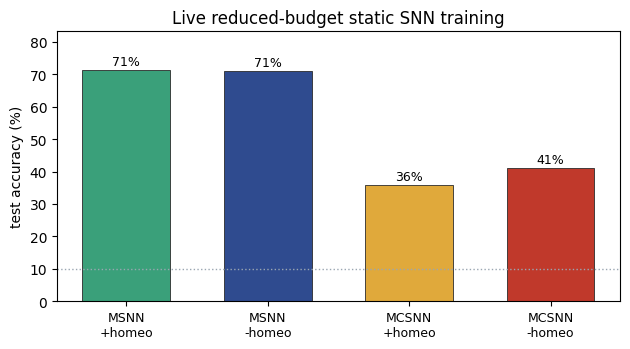

In [8]:
import json

EDGE = "#2b2b2b"
if RESULT_MODE == "live":
    labels = ["MSNN\n+homeo", "MSNN\n-homeo", "MCSNN\n+homeo", "MCSNN\n-homeo"]
    vals = [msnn_acc_h * 100, msnn_acc_nh * 100, mcsnn_acc_h * 100, mcsnn_acc_nh * 100]
    cols = [GREEN, INDIGO, GOLD, RED]
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    x = np.arange(len(labels))
    ax.bar(x, vals, color=cols, width=0.62, edgecolor=EDGE, linewidth=0.6)
    for xi, v in zip(x, vals):
        ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
    ax.axhline(10, ls=":", color=GREY, lw=1.0)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("test accuracy (%)")
    ax.set_ylim(0, max(30, min(100, max(vals) + 12)))
    ax.set_title("Live reduced-budget static SNN training")
    print("LIVE result: one-seed reduced subset; use RESULT_MODE='full_sweep_cache' for the committed multi-seed cache.")
else:
    summary = json.loads((paths.results_dir() / "publication_summary.json").read_text())
    static = summary["static_mnist"]
    print("FULL-SWEEP CACHE:", static.get("source", "publication-scale cached summary"))
    # To regenerate the cache, run the corresponding multi-seed training script used for
    # the publication-scale static MSNN/MCSNN sweep, then update data/results/publication_summary.json.
    models = ["MSNN", "MCSNN"]
    ideal = [static[m]["ideal_mean"] for m in models]
    mem = [static[m]["memristive_mean"] for m in models]
    ideal_err = [static[m]["ideal_std"] for m in models]
    mem_err = [static[m]["memristive_std"] for m in models]
    x = np.arange(len(models)); w = 0.34
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    ax.bar(x - w/2, ideal, w, yerr=ideal_err, capsize=3, color=GREY, edgecolor=EDGE, linewidth=0.6, label="ideal")
    ax.bar(x + w/2, mem, w, yerr=mem_err, capsize=3, color=TEAL, edgecolor=EDGE, linewidth=0.6, label="Poole-Frenkel")
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylabel("test accuracy (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Publication-scale static SNN training cache")
    ax.legend(frameon=False)
fig.tight_layout(); plt.show()

### Static-Classifier Result Panel
Draws the final comparative bar charts for the static MNIST classification task.


In [9]:
print("tutorial complete --", "GPU" if torch.cuda.is_available() else "CPU",
      "run; see the markdown above to scale up.")

tutorial complete -- GPU run; see the markdown above to scale up.
